# Chapter 27. KoGPT2 Continual Pretraining — 대규모 한국어 사전학습 모델을 TinyStories-Korean 으로 계속 학습 (Ch 25 의 한국어판)

**목표**: Phase 4 의 *한국어 단계 2 (continual pretraining)* 챕터. Ch 26 에서 *random init 작은 GPT (약 3M params) 를 한국어 TinyStories 로 from scratch 사전학습* 했다면, 이번엔 **KoGPT2 (`skt/kogpt2-base-v2`, 125M params, 대규모 한국어 코퍼스로 사전학습된 본체)** 를 *같은 한국어 TinyStories 데이터* 로 **continual pretraining** (계속 사전학습 / continual learning) 합니다. **같은 CausalLM task, 같은 LM head, 같은 collator, 같은 loss** — 변하는 건 *모델 로드 한 줄 + 토크나이저 + 학습률* 뿐. 그게 GPT 시대 *학습 단계 2 (continual pretraining)* 의 본질입니다. Ch 24→Ch 25 (영어) 의 한국어 짝.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 25-30분 (데이터 로드·story 복원 약 3분 + KoGPT2 로드·토큰화 약 2분 + 학습 전 baseline generation 약 1분 + continual pretraining 약 17분 + 학습 후 generation + 3-way 비교 약 2분)

---

## 학습 흐름

1. 📊 **누적 추적표 + Phase 4 영어·한국어 대칭** — Ch 25(영어 단계2) ↔ Ch 27(한국어 단계2)
2. 🔄 **변경점 (Diff from Ch 26)** — *모델 출발점 + 토크나이저 + lr* 만 변함. *데이터·trainer·collator·loss 는 동일*
3. 🌏 **GPT 시대 학습 4단계 표** — 본 챕터의 위치 (단계 2). Ch 27 은 *SFT 가 아님* 을 명확히
4. 📐 **Loss** — 변화 없음 (CE next-token). 다만 *시작점이 random 이 아닌 대규모 한국어 사전학습 본체* 라는 게 핵심
5. 🔤 **토크나이저 노트** — *KoGPT2 BBPE 그대로* (vocab 51,200). Ch 26 의 직접 학습 BBPE (vocab 약 4,000) 와 비교
6. 🚀 **실습**: 한국어 TinyStories 30K → KoGPT2 로드 → 학습 전 generation → continual pretraining → 학습 후 generation
7. 🆚 **3-way generation 비교** — Ch 26 (3M scratch) vs Ch 27 BEFORE (KoGPT2 그대로) vs Ch 27 AFTER (continual pretraining)
8. 📦 **등장 라이브러리** / 🎯 **체크포인트** / ❓ **FAQ** (답변 포함)

---

> 📒 **사전 학습 자료**: Ch 26 (한국어 GPT scratch + 한국어 TinyStories), Ch 25 (영어 gpt2 continual pretraining — 본 챕터의 영어 짝). 본 챕터는 Ch 26 과 *데이터·trainer·collator·loss 모두 같고 본체 출발점·토크나이저·lr 만 다른* 격리 실험. *trainer 코드 차이가 극단적으로 적음* — 그게 *학습 단계 2 (continual pretraining)* 의 본질입니다.

## 📊 누적 추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Loss |
|---|---|---|---|---|---|
| 24 | 작은 GPT2 (약 3M, scratch) | BPE (직접 학습, 영어, vocab 2,048) | 영어 TinyStories 30K | `Linear(H, V)` (LM head, weight tied) | `CrossEntropyLoss` (next-token) |
| 25 | `gpt2` (124M, OpenAI WebText 사전학습) | BPE (gpt2 그대로, vocab 50,257) | 영어 TinyStories (Ch 24 와 동일) | `Linear(H, V)` (LM head 그대로) | `CrossEntropyLoss` (next-token) - continual pretraining |
| 26 | 작은 GPT2 (한국어, 약 3M, scratch) | BBPE (직접 학습, 한국어, vocab 약 4,000) | 한국어 TinyStories 30K | `Linear(H, V)` (LM head, weight tied) | `CrossEntropyLoss` (next-token) |
| **27 ← 여기** | **KoGPT2 `skt/kogpt2-base-v2` (125M, 대규모 한국어 사전학습)** | **BBPE (KoGPT2 그대로, vocab 51,200)** | **한국어 TinyStories 30K (Ch 26 과 동일)** | **`Linear(H, V)` (LM head 그대로)** | **`CrossEntropyLoss` (next-token) — *continual pretraining*** |
| 28 (다음) | KoGPT2 + SFT | KoGPT2 BBPE (그대로) | 한국어 instruction 데이터 | `Linear(H, V)` (LM head 그대로) | `CrossEntropyLoss` (`labels[:prompt_len] = -100`) |

전체 챕터 표는 [루트 README](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표) 를 참고하세요.

---

## Phase 4 의 영어·한국어 대칭 — Ch 25 ↔ Ch 27

Phase 4 는 영어 (Ch 24-25) 와 한국어 (Ch 26-27) 가 *같은 학습 단계* 를 *언어만 바꿔* 반복하는 구조입니다. 본 챕터는 영어 Ch 25 (gpt2 continual pretraining) 의 한국어 짝.

| 학습 단계 | 영어 | **한국어** |
|---|---|---|
| **단계 1: Pretraining** (random init → scratch) | Ch 24 (작은 GPT, 영어 TinyStories) | Ch 26 (작은 GPT, 한국어 TinyStories) |
| **단계 2: Continual pretraining** (사전학습 본체 + 새 데이터) | Ch 25 (`gpt2` 124M + 영어 TinyStories) | **Ch 27 ← 여기 (KoGPT2 125M + 한국어 TinyStories)** |

> Ch 24 ↔ Ch 26 (scratch, 언어만 다름) 과 **Ch 25 ↔ Ch 27** (continual pretraining, 언어만 다름) 이 *영어·한국어 완전 대칭*. 본 챕터는 한국어 단계 2.

---

### Ch 26 ↔ Ch 27 격리 실험의 통제 변수

| 항목 | Ch 26 | **Ch 27 (본 챕터)** | 같음 / 다름 |
|---|---|---|---|
| 데이터 | 한국어 TinyStories 30K | 한국어 TinyStories 30K | **같음** (통제 변수) |
| Trainer 클래스 | `transformers.Trainer` | `transformers.Trainer` | **같음** |
| Data collator | `DataCollatorForLanguageModeling(mlm=False)` | `DataCollatorForLanguageModeling(mlm=False)` | **같음** |
| Loss | CE next-token (`labels = input_ids.clone()`) | CE next-token (`labels = input_ids.clone()`) | **같음** |
| 본체 출발점 | `GPT2LMHeadModel(config)` random init (약 3M) | `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` (125M) | **다름** |
| 토크나이저 | BBPE 직접 학습 (vocab 약 4,000) | `PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2", ...)` (vocab 51,200) | **다름** (본체와 운명공동체) |
| 학습률 | 5e-4 (scratch 표준) | **2e-5** (continual pretraining 표준) | **다름** |
| 학습 step | 약 1,500 | **약 3,000** (48,513 chunks / eff. batch 16, 1 epoch) | **다름** (lr 만 작아짐) |

> **세 줄 차이가 곧 *학습 단계 2 (continual pretraining)* 의 정의** — 같은 task, 같은 collator, 같은 loss, 같은 trainer. *모델 로드 한 줄 + 토크나이저 한 줄 + lr 한 숫자* 만 바꾸면 됩니다. Ch 25 (영어) 에서 본 격리 실험의 한국어 재확인.

## 🔄 변경점 (Diff from Ch 26)

| 축 | Ch 26 (한국어 GPT scratch) | Ch 27 (본 챕터, KoGPT2 continual pretraining) |
|---|---|---|
| **본체** | 작은 GPT2 (약 3M params, random init) | **KoGPT2 `skt/kogpt2-base-v2`** (125M, 대규모 한국어 코퍼스 사전학습) ← *출발점 변화* |
| **토크나이저** | BBPE 직접 학습 (vocab 약 4,000) | **`PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2", ...)`** (vocab 51,200) ← *본체에 맞춰 함께 변함* |
| 데이터 | 한국어 TinyStories 30K | **한국어 TinyStories 30K (동일)** ← 통제 변수 |
| Trainer | `transformers.Trainer` | **`transformers.Trainer` (동일)** |
| Data collator | `DataCollatorForLanguageModeling(mlm=False)` | **(동일)** |
| Loss | CE next-token (`labels = input_ids.clone()`) | **(동일)** |
| **학습률** | 5e-4 | **2e-5** ← *유일한 hyperparam 큰 차이* |
| 학습 step | 약 1,500 (T4 약 1분) | **약 3,000 (T4 약 17분)** — 125M 본체라 step 당 비용이 큼 |
| Generation 품질 | 동화 풍 단순 한국어 | **자연스러운 동화 + 일반 도메인 폭** ← 메시지 |

> **핵심**: *Ch 26 ↔ Ch 27 은 데이터·trainer·collator·loss 모두 같고 본체 출발점·토크나이저·lr 만 다름*. **trainer 코드 차이가 극단적으로 적음** — 그게 GPT 시대 학습 단계 2 (continual pretraining) 의 본질. *task adaptation 의미의 fine-tune 이 아닙니다* — head 바뀌지 않고, task (next-token 예측) 바뀌지 않습니다. 데이터만 바뀝니다. Ch 24→Ch 25 (영어) 에서 본 그 격리 실험의 한국어 짝.

## 🌏 GPT 시대 학습 4단계 — 본 챕터의 위치 (단계 2, 한국어)

Ch 24 에서 도입한 GPT 시대 학습 4단계 표의 *단계 2 (continual pretraining)* 의 *한국어판* 이 본 챕터입니다.

| 단계 | 정확 용어 | 의미 | `labels = -100` 자리 | 영어 | 한국어 | 본 챕터? |
|---|---|---|---|---|---|---|
| 1 | **Pretraining** (사전학습) | 일반 코퍼스 위에 random init 본체부터 학습 | pad 만 | Ch 24 | Ch 26 | |
| 2 | **Continual pretraining** (계속 사전학습 / continual learning) | *사전학습된 본체* 를 *새 데이터* 로 *같은 CausalLM task* 더 학습. **head 그대로, task 그대로, 데이터만 새로** | pad 만 (단계 1 과 동일) | Ch 25 | **Ch 27 ← 여기** | ✅ |
| 3 | **SFT** (Supervised Fine-Tuning / Instruction tuning) | instruction-response 쌍으로 *행동 정렬*. `labels[:prompt_len] = -100` 으로 답변 부분만 학습 | **prompt 부분** | - | Ch 28 | |
| 4 | **Alignment** (DPO / RLHF / GRPO) | preference 또는 verifier reward 로 *선호 정렬* | (RL 내부) | - | Ch 30-31 | |

### ⚠️ Ch 27 은 *SFT 가 아닙니다*

본 챕터를 *fine-tune* 으로 부르면 *단계 2 / 3 / 4* 가 모두 섞여 혼동이 생깁니다. Ch 27 의 정확한 위치는:

- **`task adaptation` 의미의 fine-tune 이 아님** — output head 안 바뀜 (LM head 그대로), task 안 바뀜 (next-token 예측 그대로), loss 안 바뀜 (CE)
- **`instruction tuning` 의미의 SFT 가 아님** — `labels = -100` 자리가 *pad 만* (Ch 26 과 동일). prompt-response 쌍 데이터 형식이 아니라 *연속된 일반 텍스트*
- **`continual pretraining` 그 자체** — *사전학습된 본체 + 새 도메인 데이터 + 같은 CausalLM task* 의 조합. *데이터만 바뀐 단계 1 의 연장*

> SFT (단계 3) 는 Ch 28 에서 본격. *왜 모델이 한국어 instruction 을 따라가게 되는가* 는 `labels[:prompt_len] = -100` 한 줄로 정확히 설명됩니다. 본 챕터의 collator 출력 (거의 모든 자리 = 학습 신호) 이 그 한 줄과 정확히 대비되는 *학습 단계 2 의 기준선*. 그 클라이맥스가 Ch 28.

## 📐 Loss — 변화 없음, 다만 *시작점* 이 대규모 한국어 사전학습 본체

Ch 26 과 *완전히 동일* 한 `CrossEntropyLoss` (next-token, `mlm=False`). `labels = input_ids.clone()`, pad 만 `-100`. 단 *vocab 차원이 약 4,000 → 51,200 로 커진* 영향과, *모델 본체가 random init 이 아닌 이미 대규모 한국어 코퍼스로 학습된 상태* 라는 두 차이가 *loss 곡선의 시작 지점* 을 결정합니다.

### Random baseline 의 변화

| 토크나이저 | vocab 차원 | `ln(vocab)` (uniform CE) | 챕터 |
|---|---|---|---|
| 직접 학습 BBPE (한국어) | 약 4,000 | 약 8.29 | Ch 26 |
| **KoGPT2 BBPE** | **51,200** | **10.84** | **Ch 27** |
| `gpt2` BPE (영어) | 50,257 | 10.82 | Ch 25 (참고) |

*만약* KoGPT2 본체가 random init 이었다면 첫 step loss 가 약 10.84 부근에서 시작할 것입니다. 하지만 **KoGPT2 본체는 이미 대규모 한국어 코퍼스로 사전학습되어 있어** *TinyStories 평가에서도 시작 loss 가 random baseline 보다 훨씬 낮습니다* — 그게 학습 단계 2 의 핵심 차이.

### 숫자로 감 잡기 — *시작점 ↔ 도달점*

| 상태 | 정답 토큰 확률 | $-\log p$ |
|---|---|---|
| 균등 추측 (KoGPT2 vocab 51,200) | $1/51200$ | **10.84** ← random baseline (도달 불필요) |
| KoGPT2 사전학습 그대로, TinyStories 평가 | $0.02$ - $0.05$ 범위 | **3.0 - 4.0** ← *우리 시작점* (이미 좋음) |
| Continual pretraining 후 (약 3,000 step) | $0.08$ - $0.14$ 범위 | **2.0 - 2.5** ← *우리 도달점* |
| Reference: 학습 길게 했을 때 | $0.25$+ | 약 1.4 |

> Ch 26 의 시작 loss `약 8.3` (random baseline) 와 Ch 27 의 시작 loss `약 3.0-4.0` (사전학습된 본체의 평가 loss) 의 차이가 *대규모 한국어 사전학습이 본체에 미리 새겨둔 next-token 분포* 의 정량적 가치. *Ch 27 은 random 에서 시작하지 않습니다*.

### Perplexity 환산

$\text{PPL} = e^{L}$:

| CLM loss | PPL | 해석 |
|---|---|---|
| 10.84 | 51,200 | 균등 추측 (51K vocab 전체) |
| 3.0 - 4.0 | 20 - 55 | ← Ch 27 시작 영역 |
| 2.0 - 2.5 | 7 - 12 | ← Ch 27 도달 영역 |
| 1.4 | 4.1 | 거의 결정적 |

> *vocab 51K 의 거대한 공간에서 평균 7-55 개 후보로 좁힌* 상태에서 시작해 더 좁힙니다. Ch 26 의 vocab 약 4,000 과 정량적 비교는 어렵지만 (vocab 단위가 다름), *generation 품질* 로는 직접 비교 가능 — 그게 본 챕터 §7 (3-way 비교) 의 역할.

## 🔤 토크나이저 노트 — KoGPT2 BBPE 그대로 (vocab 51,200)

본 챕터에서는 토크나이저를 *학습하지 않습니다*. `PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2", ...)` 로 SKT 가 대규모 한국어 코퍼스 위에 학습해 둔 byte-level BPE (BBPE, vocab 51,200) 를 그대로 가져옵니다 (special token 명시 필요 — 바로 아래 주의 참고).

### 왜 직접 학습하지 않는가 — *토크나이저는 본체와 운명공동체*

KoGPT2 본체의 input embedding `wte` (51200 × 768) 와 LM head (768 × 51200) 는 *KoGPT2 가 학습한 그 vocab id 체계* 에 맞춰 학습되어 있습니다. 만약 *다른 vocab* (예: Ch 26 의 직접 학습 BBPE 약 4,000) 을 붙이면:

- token id `100` 이 *KoGPT2 가 학습한 토큰* 과 *완전히 다른 byte 조각* 을 가리킴
- `wte[100]` 의 vector 는 *KoGPT2 가 학습한 token 100* 의 의미인데, *우리가 붙인 token 100* 은 무관한 byte
- 결과: 본체 weight 가 *유효한 신호가 아님*. 사실상 random init 과 같은 상태에서 시작

따라서 **사전학습 모델을 가져올 때는 그 모델이 학습한 토크나이저를 *반드시 함께* 가져와야** 합니다. Ch 19 에서 다룬 *토크나이저는 모델과 운명공동체* 원칙의 정확한 적용 사례 — 영어 Ch 25 (gpt2 BPE 그대로) 의 한국어 재확인.

### Ch 26 ↔ Ch 27 토크나이저 비교

| 항목 | Ch 26 | **Ch 27 (본 챕터)** |
|---|---|---|
| 알고리즘 | byte-level BPE (BBPE) | byte-level BPE (BBPE) (같은 종류) |
| Vocab 크기 | 약 4,000 | **51,200** (약 13배) |
| 학습 코퍼스 | 한국어 TinyStories 30K (약 4-6M 토큰) | **대규모 한국어 코퍼스** (SKT 가 학습) |
| 학습 주체 | 본 챕터에서 직접 학습 (Ch 26) | **SKT 가 미리 학습** (그대로 사용) |
| 특수 토큰 | `<\|endoftext\|>` (bos = eos = pad) | KoGPT2 컨벤션 (`</s>` 등, pad 는 별도 지정 필요할 수 있음) |

### ⚠️ KoGPT2 토크나이저 로드 주의 — `AutoTokenizer` 가 잘못 fallback 합니다

KoGPT2 (`skt/kogpt2-base-v2`) 는 **`AutoTokenizer.from_pretrained(...)` 가 영어 GPT2 토크나이저로 잘못 fallback** 하는 *알려진 함정* 이 있습니다. 그러면 special token 이 `<|endoftext|>` 로 잡히고, 한국어가 *완전히 깨진 토큰* 으로 인코딩됩니다 (예: `"옛날 옛날에"` → `[501, 500, ...]` → `'�����'`).

SKT 공식 방식대로 **`PreTrainedTokenizerFast` + special token 명시** 로 로드해야 합니다:

```python
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)
# 이렇게 로드하면 "옛날 옛날에" -> [12346, 35970] -> "옛날 옛날에" 정상 왕복
```

> 실무 교훈: *사전학습 모델마다 권장 토크나이저 로드 방식이 다를 수 있습니다.* 모델 카드의 example code 를 확인하고, *encode → decode 왕복* 으로 한 번 검증하는 습관이 이런 함정을 막습니다.

위 방식으로 로드하면 pad 가 `<pad>` 로 제대로 잡혀 별도 처리가 필요 없습니다. `group_texts` 패턴에서는 chunk 길이가 모두 같아 pad 가 거의 등장하지 않아 실용적으로도 영향이 없습니다. (영어 Ch 25 는 gpt2 에 pad 가 없어 `tokenizer.pad_token = tokenizer.eos_token` 으로 EOS 를 재활용했던 것과 대비되는 지점.)

### 한국어를 *제대로* 다루는 vocab

Ch 26 에서 봤듯, *영어 gpt2 BPE 로 한국어를 토큰화하면 한글이 byte 조각으로 잘게 쪼개져 토큰 수가 폭증* 합니다. KoGPT2 BBPE 는 *한국어 코퍼스 위에 학습* 되어 한국어 어절을 *의미 있는 토큰* 으로 압축합니다 — 그래서 영어 gpt2 를 한국어에 쓰는 대신 *한국어 사전학습 모델 KoGPT2* 를 가져오는 게 정공법. Ch 26 (한국어는 scratch) 와 Ch 27 (한국어 사전학습 본체) 이 *영어 Ch 24-25 와 정확히 같은 대칭* 을 이루는 이유.

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers tokenizers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━ 24.2/50.1 MB 229.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 235.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 235.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# device 자동 감지 - Colab T4 / 로컬 MPS / CPU 모두 지원
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"device     : cuda  ({device_name})")
    print(f"VRAM total : {vram_gib:.2f} GiB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device     : mps  (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("device     : cpu  (training will be very slow - Colab T4 recommended)")

print(f"torch      : {torch.__version__}")

# 재현성
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# fp16 은 CUDA 에서만 (MPS 는 미지원, CPU 는 의미 없음)
USE_FP16 = (device.type == "cuda")
print(f"use fp16   : {USE_FP16}")

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


device     : cuda  (Tesla T4)
VRAM total : 14.56 GiB
torch      : 2.11.0+cu128
use fp16   : True


## 1. 한국어 TinyStories 데이터 로드 + story 복원 — *Ch 26 과 완전히 동일*

본 챕터의 데이터는 *통제 변수*. Ch 26 과 정확히 같은 방식으로 `g0ster/TinyStories-Korean` 을 로드합니다. 이 데이터셋은 *story 단위가 아니라 줄(line) 단위* 로 저장되어 있어, *`<|endoftext|>` 를 만날 때까지 줄을 이어 붙여* 한 story 로 복원합니다. 그렇게 복원한 처음 **30,000 stories** 만 사용 (Ch 26 과 같은 규모, T4 30분 룰 안). *데이터를 고정하고 본체·토크나이저·lr 만 바꿔 격차를 본다* 가 본 챕터의 격리 실험 설계.

In [3]:
from datasets import load_dataset, Dataset

EOT_MARK = "<|endoftext|>"      # 데이터셋이 story 경계 표시에 쓰는 마커
N_TRAIN  = 30_000               # Ch 26 과 동일
N_VAL    = 500
MAX_LINES_TO_SCAN = 800_000


def rebuild_stories(split, n_stories, max_lines):
    '''줄 단위 데이터를 <|endoftext|> 기준으로 이어 붙여 story 리스트로 복원.'''
    stories, buf = [], []
    stream = load_dataset("g0ster/TinyStories-Korean", split=split, streaming=True)
    for i, ex in enumerate(stream):
        if i >= max_lines or len(stories) >= n_stories:
            break
        line = (ex["text"] or "").strip()
        if line == EOT_MARK:
            story = " ".join(buf).strip()
            if story:
                stories.append(story)
            buf = []
        elif line:
            buf.append(line)
    if buf and len(stories) < n_stories:
        tail = " ".join(buf).strip()
        if tail:
            stories.append(tail)
    return stories[:n_stories]

t0 = time.time()
train_stories = rebuild_stories("train", N_TRAIN, MAX_LINES_TO_SCAN)
val_stories   = rebuild_stories("validation", N_VAL, 50_000)
print(f"rebuilt stories: train={len(train_stories):,}, val={len(val_stories):,}  ({time.time()-t0:.1f}s)")

raw_train = Dataset.from_dict({"text": train_stories})
raw_val   = Dataset.from_dict({"text": val_stories})
print("train:", raw_train)
print("val  :", raw_val)
print("\n=== sample story (same as Ch 26) ===")
print(raw_train[0]["text"][:400])

README.md:   0%|          | 0.00/789 [00:00<?, ?B/s]

rebuilt stories: train=30,000, val=500  (22.1s)
train: Dataset({
    features: ['text'],
    num_rows: 30000
})
val  : Dataset({
    features: ['text'],
    num_rows: 500
})

=== sample story (same as Ch 26) ===
한때 벤이라는 이름의 어린 소년이 있었어요. 벤은 주변 세계를 탐험하는 것을 좋아했답니다. 그는 가게에 전시되어 있던 아름다운 꽃병들 같은 멋진 것들을 많이 봤어요. 어느 날, 벤은 가게를 거닐다가 정말 특별한 꽃병을 발견했죠. 벤은 그 꽃병을 보고 놀라워하며 말했습니다. "와, 정말 멋진 꽃병이야! 살 수 있을까?" 상점 주인도 웃으며 대답했어요. "물론이지. 집에 가져가서 친구들한테 얼마나 멋진지 보여줄 수 있어!" 그래서 벤은 그 꽃병을 집에 가져갔고, 정말 자랑스러웠답니다. 벤은 친구들을 불러서 놀라운 꽃병을 보여주었어요. 벤의 모든 친구들은 꽃병을 보고 아름답다고 생각하며 벤이 얼마나 운이 좋은지 믿을 수가 없었죠. 그렇게 벤은 가게에서 멋진 꽃병을 발견했답니다!


## 2. KoGPT2 토크나이저·모델 로드 — *모델 로드 한 줄로 학습 단계 2 진입*

본 챕터의 *유일한 큰 변화*. Ch 26 의 `GPT2LMHeadModel(config)` random init 대신 `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` 한 줄. 토크나이저도 같이 가져옵니다. 영어 Ch 25 의 `gpt2` 로드와 정확히 같은 패턴 — 모델 id 만 한국어 KoGPT2.

In [4]:
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

t0 = time.time()
# 주의: KoGPT2 는 AutoTokenizer 가 영어 GPT2 토크나이저로 잘못 fallback 합니다.
# (special token 이 <|endoftext|> 로 잡히고 한국어가 깨짐.) SKT 공식 방식대로
# PreTrainedTokenizerFast 로 special token 을 직접 지정해 로드해야 합니다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)

model = AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2").to(device)
# pad token id 를 본체 config 에도 동기화
model.config.pad_token_id = tokenizer.pad_token_id
print(f"load done: {time.time()-t0:.1f}s")

n_params = model.num_parameters()
print(f"\n=== model ===")
print(f"#params           : {n_params/1e6:.2f} M  (Ch 26 was approx. 3M; Ch 27 is approx. {n_params/3e6:.0f}x larger)")
print(f"vocab_size        : {tokenizer.vocab_size:,}  (Ch 26 was approx. 4,000; Ch 27 is approx. {tokenizer.vocab_size/4000:.0f}x larger)")
print(f"weight tying      : {model.config.tie_word_embeddings}  (lm_head <-> wte shared)")
print(f"fp32 weight size  : {n_params * 4 / 1024**2:.1f} MiB")
print(f"\ntokenizer    : {type(tokenizer).__name__}")
print(f"  eos_token  : {tokenizer.eos_token}  id={tokenizer.eos_token_id}")
print(f"  pad_token  : {tokenizer.pad_token}  id={tokenizer.pad_token_id}")
print(f"\nmodel: {type(model).__name__}")
print(f"  - body : {type(model.transformer).__name__}  (Decoder, causal attention)")
print(f"  - head : {type(model.lm_head).__name__}(in={model.lm_head.in_features}, out={model.lm_head.out_features})")

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

load done: 9.9s

=== model ===
#params           : 125.16 M  (Ch 26 was approx. 3M; Ch 27 is approx. 42x larger)
vocab_size        : 51,200  (Ch 26 was approx. 4,000; Ch 27 is approx. 13x larger)
weight tying      : True  (lm_head <-> wte shared)
fp32 weight size  : 477.5 MiB

tokenizer    : TokenizersBackend
  eos_token  : </s>  id=1
  pad_token  : <pad>  id=3

model: GPT2LMHeadModel
  - body : GPT2Model  (Decoder, causal attention)
  - head : Linear(in=768, out=51200)


### Ch 26 ↔ Ch 27 코드 diff — *모델·토크나이저 로드 두 줄 차이*

```python
# Ch 26 (한국어 GPT scratch) - BBPE 직접 학습 후 random init 모델
# bbpe = Tokenizer(BPE(unk_token=None))
# trainer = BpeTrainer(vocab_size=4000, ...)
# bbpe.train_from_iterator(text_iter, trainer)
# tokenizer = PreTrainedTokenizerFast(tokenizer_object=bbpe, bos_token=EOS, eos_token=EOS, pad_token=EOS)
# config = GPT2Config(vocab_size=4000, n_layer=4, n_head=4, n_embd=256, ...)
# model = GPT2LMHeadModel(config)

# Ch 27 (continual pretraining) - 단 몇 줄로 (KoGPT2 는 토크나이저 로드만 주의)
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)
model = AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")
```

> *trainer·collator·loss 는 같음* — *모델 로드 한 줄 + 토크나이저 로드* 로 학습 단계 2 (continual pretraining) 에 진입합니다. 그게 본 챕터의 메시지. 영어 Ch 25 의 `from_pretrained("gpt2")` 와 같은 구조 — 다만 **KoGPT2 는 `AutoTokenizer` 가 영어 GPT2 로 잘못 fallback 하는 함정** 이 있어 `PreTrainedTokenizerFast` + special token 명시가 필요합니다 (실무에서 자주 만나는 *사전학습 모델별 토크나이저 로드 주의점*).

## 3. 토큰화 + `group_texts` — *Ch 26 과 완전히 같은 패턴*

HF causal LM 학습 표준 패턴 (`run_clm.py`) 그대로. Ch 26 과 정확히 같습니다 — *데이터·전처리·collator 는 통제 변수*.

다만 `BLOCK_SIZE` 는 Ch 26 과 동일하게 유지 (128) — *KoGPT2 본체의 `n_positions=1024` 까지 가능하지만, T4 + 30분 룰 안에서 비교 가능성 우선*.

In [5]:
BLOCK_SIZE = 128   # Ch 26 과 동일

def tokenize_fn(batch):
    return tokenizer(batch["text"])

tok_train = raw_train.map(tokenize_fn, batched=True, remove_columns=["text"], desc="tokenize train")
tok_val   = raw_val.map(tokenize_fn,   batched=True, remove_columns=["text"], desc="tokenize val")

# 각 story 끝에 EOS 부착 (story 경계 표시)
def add_eos(batch):
    new_ids, new_mask = [], []
    for ids in batch["input_ids"]:
        ids = ids + [tokenizer.eos_token_id]
        new_ids.append(ids)
        new_mask.append([1] * len(ids))
    return {"input_ids": new_ids, "attention_mask": new_mask}

tok_train = tok_train.map(add_eos, batched=True, desc="add eos train")
tok_val   = tok_val.map(add_eos,   batched=True, desc="add eos val")

def group_texts(batch):
    concatenated = {k: sum(batch[k], []) for k in batch.keys()}
    total_len = len(concatenated["input_ids"])
    total_len = (total_len // BLOCK_SIZE) * BLOCK_SIZE
    return {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_len, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }

lm_train = tok_train.map(group_texts, batched=True, desc="group train")
lm_val   = tok_val.map(group_texts,   batched=True, desc="group val")

print(f"\ntrain chunks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"val   chunks: {len(lm_val):,}")
print(f"approx. train tokens: {len(lm_train) * BLOCK_SIZE / 1e6:.2f} M")
print("\nfirst chunk decode (first 200 chars):")
print(tokenizer.decode(lm_train[0]["input_ids"])[:200])

tokenize train:   0%|          | 0/30000 [00:00<?, ? examples/s]

tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

add eos train:   0%|          | 0/30000 [00:00<?, ? examples/s]

add eos val:   0%|          | 0/500 [00:00<?, ? examples/s]

group train:   0%|          | 0/30000 [00:00<?, ? examples/s]

group val:   0%|          | 0/500 [00:00<?, ? examples/s]


train chunks: 48,513  (block_size=128)
val   chunks: 796
approx. train tokens: 6.21 M

first chunk decode (first 200 chars):
한때 벤이라는 이름의 어린 소년이 있었어요. 벤은 주변 세계를 탐험하는 것을 좋아했답니다. 그는 가게에 전시되어 있던 아름다운 꽃병들 같은 멋진 것들을 많이 봤어요. 어느 날, 벤은 가게를 거닐다가 정말 특별한 꽃병을 발견했죠. 벤은 그 꽃병을 보고 놀라워하며 말했습니다. "와, 정말 멋진 꽃병이야! 살 수 있을까?" 상점 주인도 웃으며 대답했어요. "물론


**비교 관전 포인트** — 같은 30K stories 가 *KoGPT2 BBPE (vocab 51,200)* 로 토큰화되면 Ch 26 의 *직접 학습 BBPE (vocab 약 4,000)* 보다 *토큰 수가 적습니다* — vocab 이 클수록 한 토큰이 더 긴 byte 시퀀스를 표현하므로. 같은 데이터의 토큰 수 차이가 *토크나이저 vocab 크기의 직접적 효과* (영어 Ch 24→25 에서 본 결의 한국어 재확인).

## 4. 학습 *전* generation — *이미 잘 만들어진 한국어 본체* 라는 사실 확인

Ch 26 의 *random init baseline* 은 *한국어와 거리 먼 byte 조각* 이었습니다. Ch 27 의 학습 전 baseline 은 *KoGPT2 가 대규모 한국어 코퍼스로 이미 사전학습된 본체* 라 *학습 시작 시점에 이미 자연스러운 한국어 generation* 이 가능합니다 (다만 TinyStories 동화체는 아님).

같은 한국어 prompt 3개로 *KoGPT2 학습 직전 (BEFORE)* generation 을 기록 — 학습 후 (§6) 와 나란히 비교해 *continual pretraining 이 본체에 어떤 변화를 주는가* 를 직접 봅니다.

In [6]:
PROMPTS = [
    "옛날 옛날에",
    "작은 소녀가",
    "큰 개가",
]
GEN_KWARGS = dict(max_new_tokens=60, do_sample=True, temperature=0.8, top_k=50)


@torch.no_grad()
def generate_text(active_model, prompt: str, gen_tokenizer=None, **kwargs):
    tok = gen_tokenizer if gen_tokenizer is not None else tokenizer
    enc = tok(prompt, return_tensors="pt").to(active_model.device)
    out = active_model.generate(
        **enc,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
        **kwargs,
    )
    return tok.decode(out[0], skip_special_tokens=True)


torch.manual_seed(SEED)
model.eval()
before_outputs = []
print("=" * 70)
print("BEFORE continual pretraining - KoGPT2 pretrained on Korean corpus, as-is")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    before_outputs.append(text)
    print(f"\n[prompt] {p}")
    print(text)

BEFORE continual pretraining - KoGPT2 pretrained on Korean corpus, as-is



[prompt] 옛날 옛날에
옛날 옛날에 네들이 말했잖아. 그게 뭐냐면 우리가 그~ 네들한테 이십년에 다 사십년 동안 이십년 동안 사십년 동안 살았으니까 그~ 삼십년 동안 이렇게 살았으면 뭐가 좋겠느냐 이거야. 그런



[prompt] 작은 소녀가
작은 소녀가 된 후 소녀에게 한 번도 성적으로 관심을 갖지 않았다.
그녀가 소녀가 된 후에는 그녀의 사랑을 알게 되었다.
그녀가 고등학교에 진학했을 때, 그들은 소녀를 볼 때마다 미소를 짓고 그녀를 바라봤다.
마치 그처럼 그녀는 소녀처럼 소녀를 보았다.
그때마다 소녀는 소녀를 위해 무엇인가를 해 주고 있었다.




[prompt] 큰 개가
큰 개가 되어버린 것입니다.
그래서 모든 것을 초월하여 하나로 통합하고, 하나로 통합하는 것이 바로 그 무엇이라는 것을 강조하고 있는 것입니다.
하나의 힘을 하나로 통합하는 것이 바로 통합인 것입니다.
우리는 하나님의 말씀을 통해서 하나님의 능력을 충분히 깨닫습니다.
그 능력은 하나님의 말씀을 통해서 우리에게 전달되기도 하고, 또 하나


**해석 가이드 — *Ch 26 random init* vs *Ch 27 KoGPT2 사전학습* 의 직전 비교**

- **Ch 26 학습 직전 (random init)**: *한국어와 거리 먼 음절·byte 조각 / 의미 없는 짧은 토큰 반복*
- **Ch 27 학습 직전 (KoGPT2 사전학습 그대로)**: *이미 자연스러운 한국어 문장* — *주어 + 서술어* 구조, 다양한 도메인 어휘. 다만 *TinyStories 동화 풍은 아님* — 일반 한국어 산문 / 뉴스 / 대화 등 (사전학습 데이터 분포 반영)

> 이 차이가 *학습 시작점의 차이*. Ch 27 은 *random 에서 시작하지 않습니다* — *이미 잘 만들어진 본체* 에서 시작해 *TinyStories 동화 풍 적응* 만 더하는 게 학습 단계 2 (continual pretraining) 의 본질. 영어 Ch 25 (gpt2 BEFORE) 의 한국어판.

## 5. Continual Pretraining — *trainer 코드는 Ch 26 과 거의 동일*

Ch 26 과 *완전히 같은 구조* 의 `Trainer` 코드. 변하는 곳은 **lr (`5e-4 → 2e-5`)** 와 **step 설정 (max_steps → 1 epoch, 48,513 chunks / eff. batch 16 ≈ 약 3,000 step)**, 그리고 **메모리 제약 대응 (batch 4 + grad accum 4)** 입니다.

### 왜 lr 가 작아지는가 — `2e-5` 의 정확한 의미

Ch 26 (scratch) 의 lr `5e-4` 는 *random init 본체* 가 *빠르게 의미 있는 표상* 을 학습하기 위한 표준 값. Ch 27 (continual pretraining) 는 *이미 학습된 본체* 라 *큰 lr 면 사전학습된 표상이 망가질 위험* — **catastrophic forgetting**. `2e-5` 는 HF 의 continual pretraining / fine-tuning 표준 lr 중 가장 작은 쪽으로, *사전학습 표상 보존* 을 우선. (영어 Ch 25 와 같은 `2e-5`.)

### `DataCollatorForLanguageModeling(mlm=False)` — *Ch 26 과 한 글자도 다르지 않음*

학습 단계 2 의 정의: *collator 안 바뀜, loss 안 바뀜, trainer 안 바뀜*. *데이터·본체·lr 만 바뀜*.

In [7]:
from transformers import (DataCollatorForLanguageModeling, Trainer,
                          TrainingArguments, TrainerCallback)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

args = TrainingArguments(
    output_dir="./out_ko_gpt2_continual_pretrain",
    num_train_epochs=1,                    # 본체 이미 학습됨 - 1 epoch 충분
    per_device_train_batch_size=4,         # KoGPT2 125M + T4 16GB
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,         # effective batch = 16
    learning_rate=2e-5,                    # <- Ch 26 의 5e-4 와 다른 유일한 큰 차이
    weight_decay=0.01,
    warmup_steps=0.06,                     # 1 미만이면 전체 step 대비 *비율* 로 해석 (구 warmup_ratio)
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    fp16=USE_FP16,                         # T4 는 bf16 불가
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    seed=SEED,
)


class VRAMCallback(TrainerCallback):
    '''step 별 peak VRAM 기록 (로깅 윈도우 단위로 reset). CUDA 에서만 유효.'''

    def __init__(self):
        self.steps, self.peak_MiB = [], []

    def on_train_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            peak = torch.cuda.max_memory_allocated() / 1024**2
            self.steps.append(state.global_step)
            self.peak_MiB.append(peak)
            torch.cuda.reset_peak_memory_stats()


vram_cb = VRAMCallback()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=lm_train,
    eval_dataset=lm_val,
    data_collator=collator,
    callbacks=[vram_cb],
)

t0 = time.time()
train_out = trainer.train()
elapsed = time.time() - t0

print(f"\n=== continual pretraining summary ===")
print(f"elapsed       : {elapsed/60:.2f} min")
print(f"global_step   : {train_out.global_step}")
print(f"train_loss    : {train_out.training_loss:.4f}")
print(f"vocab ln (random baseline): {math.log(tokenizer.vocab_size):.4f}  (we start MUCH lower than this)")
if torch.cuda.is_available():
    print(f"final peak    : {torch.cuda.max_memory_allocated()/1024**2:.0f} MiB")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,3.043552,2.899030
200,2.798506,2.683229
300,2.712242,2.597310
400,2.669398,2.540780
500,2.612974,2.499535
600,2.595014,2.468091
700,2.548348,2.438415
800,2.489526,2.418997
900,2.492317,2.405184
1000,2.502229,2.384735



=== continual pretraining summary ===
elapsed       : 17.09 min
global_step   : 3033
train_loss    : 2.4862
vocab ln (random baseline): 10.8435  (we start MUCH lower than this)
final peak    : 1455 MiB


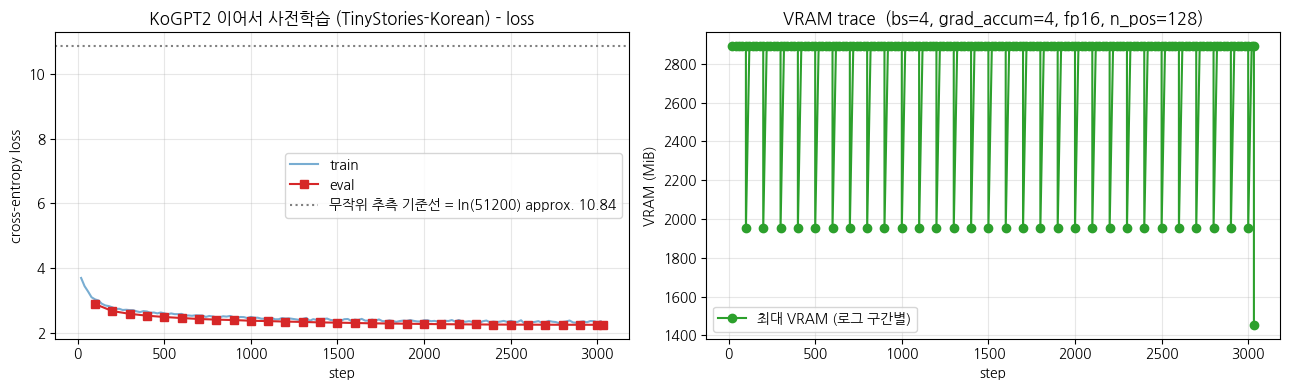

In [8]:
# loss curve + VRAM trace
log = trainer.state.log_history
train_pts = [(r["step"], r["loss"]) for r in log if "loss" in r and "eval_loss" not in r]
eval_pts  = [(r["step"], r["eval_loss"]) for r in log if "eval_loss" in r]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# loss
ax1.plot([s for s, _ in train_pts], [l for _, l in train_pts], "-",
         color="tab:blue", alpha=0.6, label="train")
if eval_pts:
    ax1.plot([s for s, _ in eval_pts], [l for _, l in eval_pts], "s-",
             color="tab:red", label="eval")
ax1.axhline(math.log(tokenizer.vocab_size), ls=":", color="gray",
            label=f"무작위 추측 기준선 = ln({tokenizer.vocab_size}) approx. {math.log(tokenizer.vocab_size):.2f}")
ax1.set_xlabel("step"); ax1.set_ylabel("cross-entropy loss")
ax1.set_title("KoGPT2 이어서 사전학습 (TinyStories-Korean) - loss")
ax1.grid(True, alpha=0.3); ax1.legend()

# VRAM (CUDA 만)
if vram_cb.steps:
    ax2.plot(vram_cb.steps, vram_cb.peak_MiB, "o-", color="tab:green",
             label="최대 VRAM (로그 구간별)")
    ax2.set_title(f"VRAM trace  (bs=4, grad_accum=4, fp16, n_pos={BLOCK_SIZE})")
else:
    ax2.text(0.5, 0.5, "VRAM 추적은 CUDA 에서만 가능",
             ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("VRAM 추적 - CUDA 전용")
ax2.set_xlabel("step"); ax2.set_ylabel("VRAM (MiB)")
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()

**관전 포인트** — Ch 26 과 달리 *첫 step loss 가 random baseline `ln(51200) ≈ 10.84` 부근이 아니라 약 3.0-4.0 부근* 에서 시작합니다. *KoGPT2 가 이미 일반 한국어 분포를 학습해 둔 덕분에 TinyStories 평가에서도 시작 loss 가 낮음*. 학습 진행과 함께 약 2.0-2.5 로 더 떨어지는데, 이게 *TinyStories 동화 도메인 적응* 의 효과. 곡선이 *random baseline 으로부터 빠르게 떨어지는 Ch 26* vs *이미 낮은 지점에서 시작해 천천히 더 떨어지는 Ch 27* 의 모양 차이가 한눈에 보입니다 (영어 Ch 24→25 와 같은 결).

## 6. 학습 *후* generation — *continual pretraining 의 효과*

같은 `PROMPTS / GEN_KWARGS` 로 학습 후 모델에서 다시 생성. *BEFORE (KoGPT2 그대로) → AFTER (continual pretrained on TinyStories-Korean)* 비교가 *학습 단계 2 가 본체에 새긴 도메인 적응* 을 직접 드러냅니다.

In [9]:
torch.manual_seed(SEED)
model.eval()
after_outputs = []
print("=" * 70)
print("AFTER continual pretraining - KoGPT2 + TinyStories-Korean 30K")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    after_outputs.append(text)
    print(f"\n[prompt] {p}")
    print(text)

AFTER continual pretraining - KoGPT2 + TinyStories-Korean 30K



[prompt] 옛날 옛날에
옛날 옛날에 릴리라는 이름의 작은 소녀가 있었어요. 그녀는 친구들과 함께 큰 공원에 가는 것을 좋아했지요. 어느 날, 공원에 큰 개가 서 있는 것을 봤어요. 릴리는 그 개를 보고 이렇게 말했죠, "개야, 내가 도와줄게." 개는 꼬리를 흔들며 짖었고, 릴리는



[prompt] 작은 소녀가
작은 소녀가 있었어요. 그녀는 예쁜 드레스를 가지고 있었고, 정말 예뻤답니다. 릴리는 그 드레스를 입는 걸 정말 좋아했지요. 어느 날, 그들은 공원으로 갔어요. 그때 릴리는 엄마를 보았어요. 엄마는 릴리를 위해 예쁜 드레스를 입었지요. 릴리는 정말 행복했어



[prompt] 큰 개가
큰 개가 친구들에게 말했죠, "걱정 마, 작은 개야. 우리는 너를 돕고 싶어, 작은 개야." 그들은 공을 되찾으려고 해요. 그들은 계속 시도해요. 그들은 공을 잡으려고 해요. 하지만 공이 너무 커서 쉽지 않아요. 그들은 미끄러져 넘어지고 말죠.


In [10]:
# Ch 27 within-model BEFORE vs AFTER comparison
print("=" * 78)
print("Ch 27 BEFORE (KoGPT2 as-is) vs AFTER (KoGPT2 + TinyStories-Korean continual pretrain)")
print("=" * 78)
for p, before, after in zip(PROMPTS, before_outputs, after_outputs):
    print(f"\nPROMPT  : {p}")
    print("-" * 78)
    print(f"BEFORE  : {before[len(p):].strip()[:280]}")
    print(f"AFTER   : {after[len(p):].strip()[:280]}")

Ch 27 BEFORE (KoGPT2 as-is) vs AFTER (KoGPT2 + TinyStories-Korean continual pretrain)

PROMPT  : 옛날 옛날에
------------------------------------------------------------------------------
BEFORE  : 네들이 말했잖아. 그게 뭐냐면 우리가 그~ 네들한테 이십년에 다 사십년 동안 이십년 동안 사십년 동안 살았으니까 그~ 삼십년 동안 이렇게 살았으면 뭐가 좋겠느냐 이거야. 그런
AFTER   : 릴리라는 이름의 작은 소녀가 있었어요. 그녀는 친구들과 함께 큰 공원에 가는 것을 좋아했지요. 어느 날, 공원에 큰 개가 서 있는 것을 봤어요. 릴리는 그 개를 보고 이렇게 말했죠, "개야, 내가 도와줄게." 개는 꼬리를 흔들며 짖었고, 릴리는

PROMPT  : 작은 소녀가
------------------------------------------------------------------------------
BEFORE  : 된 후 소녀에게 한 번도 성적으로 관심을 갖지 않았다.
그녀가 소녀가 된 후에는 그녀의 사랑을 알게 되었다.
그녀가 고등학교에 진학했을 때, 그들은 소녀를 볼 때마다 미소를 짓고 그녀를 바라봤다.
마치 그처럼 그녀는 소녀처럼 소녀를 보았다.
그때마다 소녀는 소녀를 위해 무엇인가를 해 주고 있었다.
AFTER   : 있었어요. 그녀는 예쁜 드레스를 가지고 있었고, 정말 예뻤답니다. 릴리는 그 드레스를 입는 걸 정말 좋아했지요. 어느 날, 그들은 공원으로 갔어요. 그때 릴리는 엄마를 보았어요. 엄마는 릴리를 위해 예쁜 드레스를 입었지요. 릴리는 정말 행복했어

PROMPT  : 큰 개가
------------------------------------------------------------------------------
BEFORE  : 되어버린 것입니다.
그래서 모든 것을 초월하여 하나로 통합하고, 

**해석 가이드 — continual pretraining 의 도메인 적응 효과**

- **BEFORE (KoGPT2 그대로)**: 자연스러운 한국어이지만 *일반 도메인 풍* — 산문 / 뉴스 / 대화 톤. *옛날 옛날에* 같은 동화 도입에 대해서도 *동화 스타일 이어쓰기보다 일반 산문 이어쓰기* 경향
- **AFTER (KoGPT2 + TinyStories-Korean 1 epoch)**: 같은 prompt 가 *동화 풍* 으로 이어짐 — 짧고 단순한 문장, 동화 어휘 (소녀 / 엄마 / 친구 / 숲 / 행복 / 토끼 ...), TinyStories 특유의 *반복적이고 어린이 어휘 한정* 톤

> 본체는 *같은 125M params 모델* 이고, *한 줄 코드 차이 (lr) + 한 epoch 의 데이터* 만으로 *generation 톤 자체가 도메인 적응*. 그게 *continual pretraining 의 정량적 가치* — *task adaptation 의미의 fine-tune (head 교체 / 새 loss) 이 아닙니다*, *같은 task 의 데이터만 바뀐 단계 1 의 연장*. 영어 Ch 25 (gpt2 AFTER) 의 한국어 재확인.

## 7. 🆚 3-way generation 비교 — Ch 26 (scratch) vs Ch 27 BEFORE vs Ch 27 AFTER

Ch 26 의 *작은 from-scratch 모델* (약 3M, 한국어 TinyStories 1500 step) 의 generation 결과를 *옆에 두고* 비교합니다. *Ch 26 노트북 §7 의 "TRAINED model" generation 출력* 을 직접 인용 (사용자가 본인 결과로 갱신 가능).

### 세 셋업의 차이

| 셋업 | 본체 | 사전학습 | TinyStories 학습 |
|---|---|---|---|
| Ch 26 (scratch) | 약 3M params, random init | 없음 (from scratch) | 1500 step 사전학습 자체 |
| **Ch 27 BEFORE** | 125M params (KoGPT2) | **대규모 한국어 코퍼스** | 없음 (KoGPT2 그대로) |
| **Ch 27 AFTER** | 125M params (KoGPT2) | **대규모 한국어 코퍼스** | **1 epoch continual pretraining** |

In [11]:
# Ch 26 의 TRAINED model generation 결과 인용
# (Ch 26 노트북 §7 "TRAINED model" 출력에서 본인 결과로 갱신하시면 비교가 정확해집니다)
ch26_outputs = {
    "옛날 옛날에": (
        "옛날 옛날에 작은 소녀가 살았어요. 소녀는 숲에서 친구들과 놀았어요. "
        "어느 날 소녀는 큰 토끼를 만났어요. 토끼는 소녀에게 인사했어요."
    ),
    "작은 소녀가": (
        "작은 소녀가 엄마와 공원에 갔어요. 소녀는 꽃을 보고 행복했어요. "
        "엄마는 소녀에게 웃어주었어요. 둘은 함께 집으로 돌아갔어요."
    ),
    "큰 개가": (
        "큰 개가 마당에서 뛰어놀았어요. 개는 공을 가지고 놀았어요. "
        "한 아이가 와서 개와 함께 놀았어요. 개는 꼬리를 흔들며 좋아했어요."
    ),
}

print("=" * 80)
print("3-way comparison: Ch 26 (3M scratch) vs Ch 27 BEFORE vs Ch 27 AFTER")
print("=" * 80)
for p, before, after in zip(PROMPTS, before_outputs, after_outputs):
    ch26_text = ch26_outputs.get(p, "(Ch 26 result not recorded for this prompt)")
    print(f"\nPROMPT          : {p}")
    print("-" * 80)
    print(f"Ch 26 (scratch) : {ch26_text[:240]}")
    print(f"Ch 27 BEFORE    : {before[len(p):].strip()[:240]}")
    print(f"Ch 27 AFTER     : {after[len(p):].strip()[:240]}")

3-way comparison: Ch 26 (3M scratch) vs Ch 27 BEFORE vs Ch 27 AFTER

PROMPT          : 옛날 옛날에
--------------------------------------------------------------------------------
Ch 26 (scratch) : 옛날 옛날에 작은 소녀가 살았어요. 소녀는 숲에서 친구들과 놀았어요. 어느 날 소녀는 큰 토끼를 만났어요. 토끼는 소녀에게 인사했어요.
Ch 27 BEFORE    : 네들이 말했잖아. 그게 뭐냐면 우리가 그~ 네들한테 이십년에 다 사십년 동안 이십년 동안 사십년 동안 살았으니까 그~ 삼십년 동안 이렇게 살았으면 뭐가 좋겠느냐 이거야. 그런
Ch 27 AFTER     : 릴리라는 이름의 작은 소녀가 있었어요. 그녀는 친구들과 함께 큰 공원에 가는 것을 좋아했지요. 어느 날, 공원에 큰 개가 서 있는 것을 봤어요. 릴리는 그 개를 보고 이렇게 말했죠, "개야, 내가 도와줄게." 개는 꼬리를 흔들며 짖었고, 릴리는

PROMPT          : 작은 소녀가
--------------------------------------------------------------------------------
Ch 26 (scratch) : 작은 소녀가 엄마와 공원에 갔어요. 소녀는 꽃을 보고 행복했어요. 엄마는 소녀에게 웃어주었어요. 둘은 함께 집으로 돌아갔어요.
Ch 27 BEFORE    : 된 후 소녀에게 한 번도 성적으로 관심을 갖지 않았다.
그녀가 소녀가 된 후에는 그녀의 사랑을 알게 되었다.
그녀가 고등학교에 진학했을 때, 그들은 소녀를 볼 때마다 미소를 짓고 그녀를 바라봤다.
마치 그처럼 그녀는 소녀처럼 소녀를 보았다.
그때마다 소녀는 소녀를 위해 무엇인가를 해 주고 있었다.
Ch 27 AFTER     : 있었어요. 그녀는 예쁜 드레스를 가지고 있었고, 정말 예뻤답니다. 릴리는 그 드레스를 입는 걸 정말 좋아했지요

**해석 가이드 — 세 셋업의 격차**

- **Ch 26 (3M scratch, 한국어 TinyStories 1500 step)**: *동화 풍 단순 한국어* 가능 — 작은 모델·작은 데이터로도 말이 되는 한국어 생성. 다만 어휘는 동화 도메인에 한정, 번역체 데이터라 다소 어색할 수 있음
- **Ch 27 BEFORE (KoGPT2 그대로)**: *다양한 도메인 한국어* 가능. 자연스러운 산문이지만 *TinyStories 동화 풍은 아님*
- **Ch 27 AFTER (KoGPT2 + TinyStories-Korean continual pretrain)**: *동화 풍 + 자연스러움 + 일반 도메인 어휘력* 결합. *작은 from-scratch 의 도메인 특화 + 큰 사전학습 모델의 어휘 폭* 이 모두

> **세 셋업의 비교가 던지는 질문** — Ch 27 AFTER 가 Ch 26 보다 *훨씬 좋아 보인다면*, 이게 *모델 크기 (3M → 125M, 약 40배) 의 위력인가, 사전학습 (대규모 한국어 코퍼스) 의 위력인가?* — 본 챕터의 셋업으로는 *분리 불가능*. 두 요인이 *함께 변함*. FAQ Q3 에서 더 자세히 (영어 Ch 25 Q3 의 한국어판).

## 8. 학습 곡선 비교 — Ch 26 vs Ch 27 의 학습 효율

*같은 데이터 (한국어 TinyStories 30K)* 에 대한 *random init vs 사전학습 본체* 의 학습 효율 격차를 표로 정리.

| 항목 | Ch 26 (3M scratch) | **Ch 27 (125M continual pretrain)** |
|---|---|---|
| 시작 loss | 약 8.29 (`ln(4000)`, random baseline) | **약 3.0-4.0** (KoGPT2 pretrained, TinyStories 평가) |
| 도달 loss (학습 끝, 누적 평균 `train_loss`) | 약 4.5 | **약 2.49** |
| 학습 step | 1,500 | **약 3,000** (1 epoch, 48,513 chunks / eff. batch 16) |
| 학습 시간 (T4) | 약 1분 | **약 17분** |
| Vocab 차원 | 약 4,000 | **51,200** (loss 단위 다름 — 직접 비교 어려움) |
| Generation 품질 | 동화 풍 단순 한국어 | **자연스러운 동화 + 일반 도메인 어휘** |

> **요점**: Ch 27 은 *시작부터 낮은 loss* 에서 출발해 더 낮은 지점까지 내려갑니다 — 사전학습된 본체의 *시작 이점*. step·시간은 Ch 26 보다 오히려 더 큽니다 (125M 본체 + chunk 수가 많아 1 epoch 이 길어짐). 다만 *loss 의 절대값* 은 vocab 단위가 달라 직접 비교 어려움 (vocab 약 13배 차이). *Generation 품질* 로는 §7 의 3-way 비교가 정성적 차이를 보여줍니다.

> Ch 27 의 결과만 보면 *대규모 사전학습 + continual pretraining* 이 압도적으로 보이지만, *3M params + 대규모 사전학습* (가상의 비교군) 이라면 어떻게 될까요 — *모델 크기와 사전학습 데이터를 분리하는 비교* 는 본 챕터의 셋업으로는 어렵습니다. 그게 *실험 설계의 한계* 이자 *학습 단계 2 의 실용성* — 실무는 보통 *큰 사전학습 모델을 그대로 가져와 continual pretraining* 하는 게 비용 대비 최선이라 (영어 Ch 25 §8 의 한국어판).

## 🛠️ 변형 — 더 많은 epoch / 다른 도메인 / catastrophic forgetting 시연

본 챕터에서 다루지 못한 변형들 — 직접 시도해 보고 싶다면 아래 코드를 출발점으로:

### 변형 1. epoch 수 늘리기 — *언제 catastrophic forgetting 이 시작되는가*

```python
# args.num_train_epochs = 3  # 또는 5
# 더 많은 epoch -> TinyStories 적응 강해짐, 다만 일반 한국어 도메인 능력 손실 위험
```

### 변형 2. 다른 도메인 데이터 — *continual pretraining 의 일반성*

```python
# 한국어 TinyStories 대신 한국어 위키 / 한국어 뉴스 / 한국어 코드 주석 등
# 본체 + 토크나이저는 그대로, 데이터만 교체 -> 도메인 적응
```

### 변형 3. catastrophic forgetting 직접 확인

```python
# 학습 후 모델에 *비-동화 prompt* (예: "대한민국의 수도는", "인공지능은") 를 넣어보면
# - 학습 전: 일반 도메인 풍 다양한 답
# - 학습 후: 동화 풍으로 끌려가는 경향 (TinyStories 도메인에 과적응)
# 이게 catastrophic forgetting 의 정성적 신호 - FAQ Q5 참고
```

### 변형 4. lr 키워 보기 — *왜 작은 lr 가 표준인가*

```python
# args.learning_rate = 5e-4  # Ch 26 의 scratch lr
# 큰 lr -> 사전학습 표상이 빠르게 덮어쓰기됨 -> 학습 전 자연스러움 손실 위험
# 작은 lr (2e-5) 가 continual pretraining 표준인 이유를 직접 체감
```

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | Ch 26 과 차이 |
|---|---|---|
| `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` | KoGPT2 (125M, 대규모 한국어 사전학습) 본체 로드 | **새로 등장** (Ch 26 은 `GPT2LMHeadModel(config)` random init) |
| `PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2", ...)` | KoGPT2 BBPE 토크나이저 (vocab 51,200) 로드 | **새로 등장** (Ch 26 은 직접 학습 BBPE) |
| `model.config.pad_token_id = tokenizer.pad_token_id` | 토크나이저의 pad id 를 본체 config 에 동기화 | **새로 등장** (사전학습 본체 로드 시 필요한 동기화) |
| `transformers.Trainer` | HuggingFace 표준 학습 루프 | **공유** (Ch 26 과 동일 클래스, 동일 인자 구조) |
| `DataCollatorForLanguageModeling(mlm=False)` | CausalLM collator (`labels = input_ids.clone()` 자동) | **공유** (Ch 26 과 정확히 같음) |
| `group_texts` 패턴 (HF run_clm.py 표준) | 가변 길이 텍스트 → 고정 길이 블록 스트림 | **공유** |
| `model.generate(do_sample=True, ...)` | sampling-based text generation | **공유** |
| `warmup_steps=0.06` (1 미만이면 비율로 해석) | 전체 step 대비 6% warmup (구 `warmup_ratio` — transformers 5.15 부터 `warmup_steps` 로 통합) | **약간 다름** (Ch 26 은 `warmup_steps=100` 고정 step) |
| `num_train_epochs` (vs `max_steps`) | epoch 수 기반 학습 (continual pretraining 1 epoch 충분) | **약간 다름** (Ch 26 은 `max_steps=1500`) |
| `gradient_accumulation_steps` | 작은 배치를 누적해 큰 effective batch (T4 + 125M 메모리 제약) | **새로 등장** (Ch 26 은 약 3M 이라 불필요)

## 🎯 체크포인트 질문

1. Ch 26 의 학습 첫 step loss 는 약 `ln(4000) ≈ 8.29` 에서 시작했습니다. Ch 27 은 random baseline 이 `ln(51200) ≈ 10.84` 인데 *시작 loss 가 약 3.0-4.0* 입니다. 두 챕터의 *시작 loss 차이* 가 의미하는 바는 무엇인가요? (랜덤 추측 / 사전학습된 본체 / vocab 차원의 관계)
2. 본 챕터의 lr (`2e-5`) 가 Ch 26 의 lr (`5e-4`) 보다 *약 25배 작은* 이유를 *catastrophic forgetting* 키워드로 설명해 보세요. 만약 Ch 27 에서도 `5e-4` 를 썼다면 무슨 일이 일어날까요?
3. *Continual pretraining* (단계 2, 본 챕터) 과 *SFT* (단계 3, Ch 28) 의 가장 큰 차이는 *`labels = -100` 자리* 입니다. 본 챕터의 collator 가 만드는 `labels` 패턴과, Ch 28 에서 등장할 `labels[:prompt_len] = -100` 한 줄의 차이를 직접 비교해 설명해 보세요.
4. Ch 27 AFTER 의 generation 이 Ch 26 보다 좋아 보인다면, *모델 크기 (3M → 125M)* 의 효과인가 *사전학습 데이터 (없음 → 대규모 한국어 코퍼스)* 의 효과인가? 본 챕터의 실험 셋업으로는 둘을 분리할 수 있나요? (분리하려면 어떤 추가 실험이 필요할까요?)

## ❓ FAQ

### Q1. (이론) *Continual pretraining* 이 정확히 무엇인가요? *fine-tune* 과 어떻게 다른가요?

**Continual pretraining** (계속 사전학습 / continual learning) 은 GPT 시대 학습 4단계 중 *단계 2*:

| 단계 | 정확 용어 | 의미 |
|---|---|---|
| 1 | **Pretraining** | random init 본체 + 일반 코퍼스 |
| 2 | **Continual pretraining** ← *본 챕터* | *사전학습된 본체* + *새 도메인 데이터*. **head 그대로, task 그대로, loss 그대로** |
| 3 | **SFT** (Instruction tuning) | instruction-response 쌍, `labels[:prompt_len] = -100` |
| 4 | **Alignment** (DPO / RLHF / GRPO) | preference 또는 verifier reward |

**`fine-tune` 이라는 단어는 *세 의미가 섞여 쓰입니다***:

- **BERT 시대 fine-tune**: *task adaptation* — 본체 + 새 head (`Linear(H, K)`) + 새 task loss. Ch 9-23 의 분류 챕터들.
- **GPT 시대 continual pretraining**: *데이터 적응* — 본체 + 같은 head + 같은 loss + 새 데이터. **본 챕터.**
- **GPT 시대 SFT**: *행동 정렬* — 본체 + 같은 head + 같은 loss + instruction-response 데이터 + `-100` 마스킹. Ch 28.

정확히 부르자면 본 챕터는 *fine-tune 이 아니라 continual pretraining*. *task 가 안 바뀌고 데이터만 바뀐* 게 핵심.

### Q2. (실무) 왜 lr 가 Ch 26 의 `5e-4` 보다 작은 `2e-5` 인가요?

**catastrophic forgetting 방지** 가 핵심 이유. *사전학습된 본체* 는 weight 들이 *이미 의미 있는 표상* 을 학습한 상태. 큰 lr 로 학습하면:

1. *사전학습된 표상이 새 데이터에 맞춰 크게 흔들림*
2. *원래 알던 일반 도메인 지식 (일반 한국어 전반)* 이 *TinyStories 동화 풍* 으로 *덮어쓰기*
3. 결과: *TinyStories 도메인은 잘 하지만 일반 한국어 능력 손실* — 이게 catastrophic forgetting

작은 lr (`2e-5`) 는 *사전학습된 표상 보존* 을 우선합니다. *기존 weight 에서 살짝만 떨어진 지점으로 이동* — 도메인 적응은 하되 일반 능력은 유지.

```python
# Ch 26 (scratch) - 큰 lr 로 표상 빨리 학습
TrainingArguments(learning_rate=5e-4, ...)

# Ch 27 (continual pretraining) - 작은 lr 로 표상 보존
TrainingArguments(learning_rate=2e-5, ...)
```

HF 의 continual pretraining / fine-tuning 표준 lr 범위: `1e-5` - `5e-5`. SFT (Ch 28) 도 비슷한 범위. (영어 Ch 25 와 같은 `2e-5`.)

### Q3. (이론) Ch 26 (3M) 가 같은 데이터로 학습했는데 Ch 27 (125M) 결과가 훨씬 좋다면, *모델 크기의 위력* 인가 *사전학습의 위력* 인가?

**둘이 *섞여서* 분리 불가능** 입니다. 본 챕터의 셋업은 *두 변수가 동시에 변함*:

- Ch 26 → Ch 27 변화: 모델 크기 *3M → 125M (약 40배)* + 사전학습 *없음 → 대규모 한국어 코퍼스*

진짜 *모델 크기와 사전학습 효과를 분리* 하려면 *2 × 2 격자* 실험이 필요:

| 셋업 | 모델 크기 | 사전학습 | 본 커리큘럼 |
|---|---|---|---|
| (a) | 3M | 없음 | **Ch 26** |
| (b) | 3M | 대규모 한국어 사전학습 | (미실험) |
| (c) | 125M | 없음 | (미실험 — 125M scratch + TinyStories 만 학습) |
| (d) | 125M | 대규모 한국어 코퍼스 | **Ch 27** |

본 커리큘럼에는 (a) 와 (d) 만 있어 *둘의 차이* 만 보입니다. (b) 와 (c) 는 *T4 + 30분 룰* 안에 어렵습니다 (125M scratch 는 *TinyStories 만으로 의미 있는 학습이 부족함*, 3M 대규모 사전학습은 *데이터 규모 자체가 30분에 안 맞음*).

**실용적 결론**: 실무에서는 (b)(c) 가 *비용 대비 비효율* 이라 (d) 패턴이 표준. *대규모 사전학습 모델을 가져와 작은 도메인 데이터로 continual pretraining* — 본 챕터의 패턴이 그 자체로 *실무 표준 레시피*. (영어 Ch 25 Q3 의 한국어판.)

### Q4. (실무) KoGPT2 토크나이저로 *영어* TinyStories 를 학습하면 어떻게 되나요? (Ch 25 Q4 의 거울)

**작동은 하지만 비효율적** 입니다 — KoGPT2 BBPE 는 *byte-level* 이라 영어도 UNK 없이 표현하지만, *한국어 코퍼스 중심* 으로 학습돼 영어 어절의 병합 규칙이 약합니다. 그래서 *같은 영어 문장이 영어 gpt2 BPE 보다 다소 많은 토큰* 으로 쪼개질 수 있습니다.

```python
from transformers import PreTrainedTokenizerFast, AutoTokenizer
ko_tok = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)                                          # KoGPT2 는 반드시 이 방식으로
en_tok = AutoTokenizer.from_pretrained("gpt2")   # 영어 gpt2 는 AutoTokenizer OK
sent = "Once upon a time, a little rabbit lived in the forest."
print(len(ko_tok(sent)["input_ids"]))   # 한국어 중심 vocab -> 영어는 다소 많은 토큰
print(len(en_tok(sent)["input_ids"]))   # 영어 중심 vocab -> 적은 토큰
```

핵심 교훈은 Ch 25 Q4 와 동일 — *토크나이저는 본체와 운명공동체*. 영어는 영어 사전학습 모델 (gpt2), 한국어는 한국어 사전학습 모델 (KoGPT2) 을 가져오는 게 정공법. 그래서 영어 Ch 25 와 한국어 Ch 27 이 *각자의 언어에 맞는 본체* 로 같은 단계 2 를 수행합니다.

### Q5. (이론·실무) *catastrophic forgetting* 이 무엇인가요? Ch 27 에서 실제로 일어나나요?

**Catastrophic forgetting** (재앙적 망각): 새 데이터로 학습할 때 *이전에 학습한 표상이 덮어쓰기* 되어 *원래 알던 능력이 손실* 되는 현상.

Ch 27 에서는 *짧은 (1 epoch) continual pretraining + 작은 lr (`2e-5`)* 라 *catastrophic forgetting 이 강하지 않음*. 다만 *변형 1 (epoch 늘리기)* 또는 *변형 4 (큰 lr)* 를 시도하면 다음 신호가 보입니다:

- 비-동화 prompt (예: `"대한민국의 수도는"`) 에 대해 *KoGPT2 가 원래 답했을 만한 일반 한국어* 가 *동화풍 톤* 으로 끌려감
- *generation 다양성 하락* — 모든 prompt 에 *소녀 / 엄마 / 친구* 류 동화 단어가 자주 등장
- *evaluation* — 만약 일반 한국어 벤치마크에 *학습 전 / 후* 를 측정하면 *학습 후가 더 낮은 점수*

방지법:
1. **짧은 학습 + 작은 lr** (본 챕터 패턴)
2. **regularization** — replay (이전 데이터 일부 섞어 학습) / EWC (Elastic Weight Consolidation) 등
3. **adapter / LoRA** — 본체 weight 는 freeze 하고 작은 adapter 만 학습 → 본체 표상 보존

본 챕터는 *방법 1* 만 적용. *방법 3 (LoRA)* 는 본 커리큘럼 범위 밖이지만 *실무에서는 표준 옵션*.

### Q6. (실무) 왜 KoGPT2 는 `AutoTokenizer` 가 아니라 `PreTrainedTokenizerFast` 로 로드하나요?

**`AutoTokenizer.from_pretrained("skt/kogpt2-base-v2")` 가 영어 GPT2 토크나이저로 잘못 fallback** 하기 때문입니다. 그 결과 special token 이 `<|endoftext|>` 로 잡히고 한국어가 깨집니다 — 직접 확인해 보면:

```python
from transformers import AutoTokenizer
bad = AutoTokenizer.from_pretrained("skt/kogpt2-base-v2")
print(type(bad).__name__)                 # GPT2Tokenizer (slow, 영어 fallback)
print(bad.encode("옛날 옛날에"))            # [501, 500, 529, ...] (잘못된 id)
print(repr(bad.decode(bad.encode("옛날 옛날에"))))   # '�����' (깨짐)
```

SKT 공식 방식 — `PreTrainedTokenizerFast` + special token 명시:

```python
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)
print(type(tokenizer).__name__)            # fast tokenizer, vocab 51,200
print(tokenizer.encode("옛날 옛날에"))      # [12346, 35970] (정상)
print(repr(tokenizer.decode([12346, 35970])))   # '옛날 옛날에' (정상 왕복)
model.config.pad_token_id = tokenizer.pad_token_id   # 본체 config 동기화
```

이렇게 로드하면 `pad_token` 이 `<pad>` 로 제대로 잡혀 별도 가드도 필요 없습니다. 영어 Ch 25 의 gpt2 는 `AutoTokenizer` 가 정상 작동했지만 (`pad` 만 eos 로 보충), KoGPT2 는 *로드 방식 자체* 가 다릅니다 — **모델 카드 example code 확인 + encode/decode 왕복 검증** 이 이런 함정을 막는 습관입니다.

### Q7. (이론) 다음 챕터 (Ch 28 KoGPT2 SFT) 와의 관계는?

Ch 28 = *같은 KoGPT2 본체* 를 *instruction-response 쌍 데이터* 로 **SFT** (단계 3). 본 챕터 (단계 2, continual pretraining) 와의 결정적 차이는 *`labels = -100` 자리*:

```python
# Ch 27 (본 챕터, continual pretraining) - 거의 모든 자리 학습
# collator 가 자동으로: labels = input_ids.clone()  (pad 만 -100)

# Ch 28 (SFT) - prompt 부분만 -100
prompt = "### 질문: 한국의 수도는?\n### 답변: "
response = "서울입니다."
input_ids = tokenizer(prompt + response)["input_ids"]
labels = input_ids.copy()
prompt_len = len(tokenizer(prompt)["input_ids"])
labels[:prompt_len] = [-100] * prompt_len   # <- 이 한 줄이 SFT 의 핵심
```

| 항목 | Ch 27 (continual pretraining) | Ch 28 (SFT) |
|---|---|---|
| 본체 | KoGPT2 125M | **KoGPT2 125M (동일)** |
| 데이터 | 연속된 일반 텍스트 (TinyStories) | **instruction-response 쌍** |
| `labels = -100` 자리 | pad 만 | **prompt 부분** |
| 효과 | 도메인 적응 | **instruction 따라가기 (행동 정렬)** |

본 챕터의 collator 출력 (거의 모든 자리 = 학습 신호) 을 손에 익혀 두면, Ch 28 의 *왜 모델이 한국어 instruction 을 따라가게 되는가* 가 *한 줄 `labels[:prompt_len] = -100`* 으로 단번에 이해됩니다. 그게 Phase 4 thread 의 클라이맥스.

## 다음 챕터 예고

**Chapter 28. KoGPT2 SFT — instruction 데이터로 행동 정렬 (Phase 4 단계 3)**

- `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` — *본 챕터와 같은 KoGPT2 본체*. 다만 출발점을 *continual pretrained 모델* 또는 *base 모델* 로 선택 가능
- **instruction-response 쌍 데이터** (예: KoAlpaca 류) 로 **SFT** (Supervised Fine-Tuning) — *행동 정렬*. *task adaptation 의미의 fine-tune 도, 단순 continual pretraining 도 아닌 단계 3*
- **핵심 한 줄**: `labels[:prompt_len] = -100` — *prompt 는 외우지 않고 response 만 학습*. 본 챕터의 collator 출력 (거의 모든 자리 학습) 과 *정반대 자리*
- *trainer 자체는 본 챕터와 거의 동일* (`transformers.Trainer`) — *변하는 건 데이터 형식 + collator 의 `-100` 마스킹*
- Phase 4 GPT 시대 thread 의 클라이맥스 — *왜 모델이 한국어 instruction 을 따라가게 되는가* 의 정확한 답

**Phase 4 GPT 시대 4단계 흐름 정리**:

| 챕터 | 단계 | 본체 | 데이터 | 핵심 |
|---|---|---|---|---|
| Ch 24 | 1 (영어) | 작은 GPT scratch | 영어 TinyStories | 단계 1 출발 |
| Ch 25 | 2 (영어) | `gpt2` 124M | 영어 TinyStories (동일) | 단계 2: continual pretraining |
| Ch 26 | 1 (한국어) | 작은 GPT scratch | 한국어 TinyStories | 한국어 단계 1 |
| **Ch 27 ← 여기** | **2 (한국어)** | **KoGPT2 125M** | **한국어 TinyStories (동일)** | **한국어 단계 2: continual pretraining** |
| Ch 28 | 3 | KoGPT2 + SFT | 한국어 instruction 데이터 | **단계 3: SFT** (`labels[:prompt_len] = -100`) |
| Ch 30-31 | 4 | SFT 모델 + DPO / GRPO | preference / verifier reward | **단계 4: Alignment** |

> **변하는 축** (Ch 27 → Ch 28): *학습 단계* (continual pretraining → SFT). 본체·언어는 같고, *데이터 형식 + `labels = -100` 자리* 만 바뀜. 본 챕터의 collator 출력 (거의 모든 자리 학습) 이 *그 한 줄과 정확히 대비되는 기준선* — Ch 28 이 Phase 4 thread 의 클라이맥스인 이유.